# 2.10 Synthetic Noise
***Generation of synthetic noise and synthetic data for geoscience***

## 1. Introduction

Noise in geoscientific data comes from the environment, from the instrument, and from human activity. If we can simulate noise, we can build controlled datasets with known ground truth. That lets us test filters, benchmark detectors, and augment training sets for machine learning.

This lesson covers synthetic noise in two settings:
1. **1D time series**: seismic records, atmospheric pressure, sea surface temperature.
2. **2D geospatial fields**: topography, soil moisture, temperature maps.

We end with a realistic seismological example and a discussion of when synthetic data is admissible in research.

### Types of noise
- **White noise**: constant power spectral density at all frequencies. Typical of instrumental noise.
- **Pink noise**: power spectral density proportional to $1/f$. Common in natural systems such as climate records.
- **Gaussian noise**: noise whose amplitude distribution is normal. White noise is often drawn from a Gaussian.
- **Spatially correlated noise**: noise that varies smoothly over space, as in atmospheric or sensor artifacts in maps.

Throughout this notebook we use numpy's modern random generator, seeded for reproducibility. Seeding matters: a synthetic dataset that cannot be regenerated is not reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 2. Noise models in 1D and 2D

### 2.1 White and pink noise (1D)

White noise is a sequence of independent Gaussian draws. Pink noise is built in the frequency domain: we impose an amplitude spectrum proportional to $1/\sqrt{f}$ (so the *power* goes as $1/f$), draw random phases, and transform back to the time domain. We use `np.fft.irfft`, which takes the spectrum at non-negative frequencies only and returns a real signal by construction.

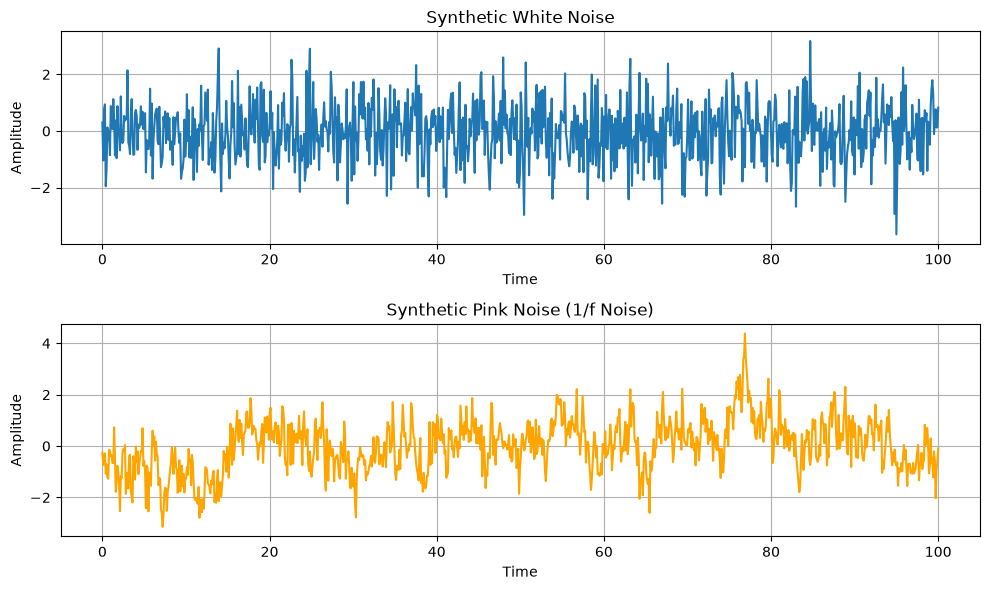

In [2]:
n = 1000  # number of time points
time = np.linspace(0, 100, n)

# White noise: independent Gaussian draws, zero mean
white_noise = rng.standard_normal(n)


def generate_pink_noise(size, rng):
    """Pink (1/f) noise: power spectral density proportional to 1/f.

    Build the one-sided spectrum with amplitude 1/sqrt(f) and random
    phases, then invert with irfft to get a real time series.
    """
    freqs = np.fft.rfftfreq(size)
    amplitude = np.zeros_like(freqs)
    amplitude[1:] = 1.0 / np.sqrt(freqs[1:])  # skip f=0 to avoid division by zero
    phases = rng.uniform(0, 2 * np.pi, len(freqs))
    spectrum = amplitude * np.exp(1j * phases)
    pink = np.fft.irfft(spectrum, n=size)
    return pink / np.std(pink)


pink_noise = generate_pink_noise(n, rng)

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(time, white_noise, label='White Noise')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Synthetic White Noise')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time, pink_noise, label='Pink Noise', color='orange')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Synthetic Pink Noise (1/f Noise)')
plt.grid()

plt.tight_layout()
plt.show()

The white noise fluctuates rapidly with no memory from sample to sample. The pink noise wanders: low frequencies carry most of the power, so the series drifts on long time scales.

**Applications.** White noise simulates instrumental self-noise in seismic or atmospheric records. Pink noise mimics natural variability, which is dominated by low frequencies in many geophysical processes.

### 2.2 Spatially correlated noise (2D)

Geospatial noise is rarely independent from pixel to pixel. Atmospheric interference and sensor drift vary smoothly over space. A simple way to simulate this: generate a 2D field of white noise, then smooth it with a Gaussian filter. The filter width sets the correlation length.

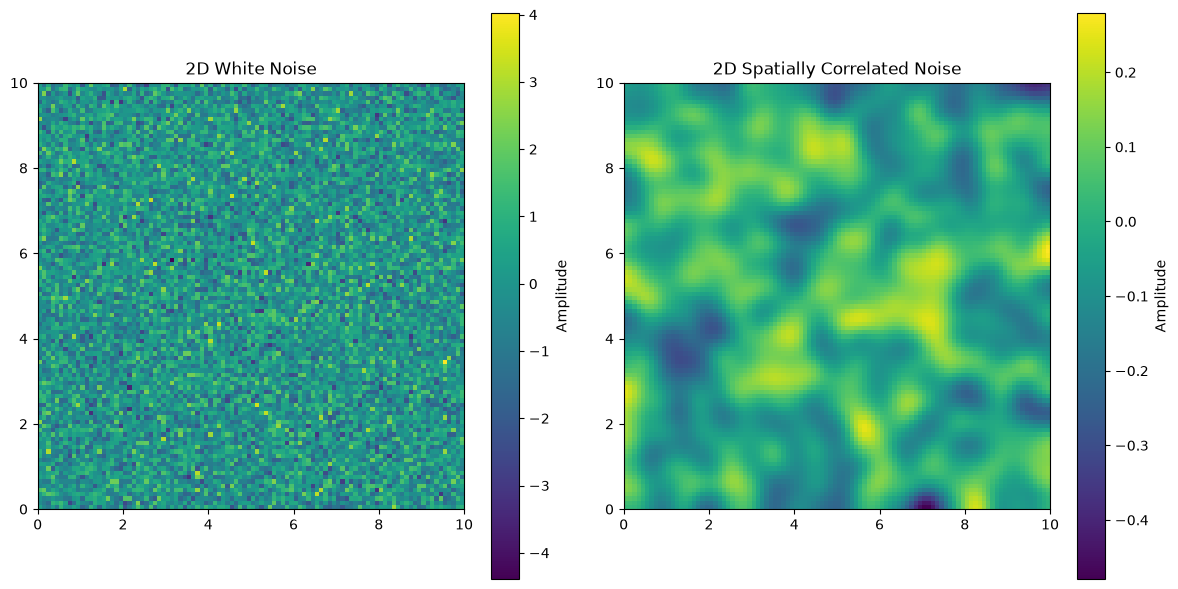

In [3]:
from scipy.ndimage import gaussian_filter

ngrid = 100  # size of the grid
x = np.linspace(0, 10, ngrid)
y = np.linspace(0, 10, ngrid)
X2d, Y2d = np.meshgrid(x, y)

# 2D white noise
white_noise_2d = rng.standard_normal((ngrid, ngrid))

# Spatially correlated noise: smooth the white noise
spatially_correlated_noise = gaussian_filter(white_noise_2d, sigma=3)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(white_noise_2d, extent=[0, 10, 0, 10], cmap='viridis')
plt.colorbar(label='Amplitude')
plt.title('2D White Noise')

plt.subplot(1, 2, 2)
plt.imshow(spatially_correlated_noise, extent=[0, 10, 0, 10], cmap='viridis')
plt.colorbar(label='Amplitude')
plt.title('2D Spatially Correlated Noise')

plt.tight_layout()
plt.show()

**Applications.** Spatially correlated noise simulates atmospheric distortion in satellite imagery, interpolation artifacts in gridded products, and smooth sensor errors in geophysical maps.

## 3. Synthetic transient events

We now build a time series that contains one transient event plus noise. This is the basic ingredient of a binary classification problem: does a window contain **signal** or only **noise**?

### 3.1 Event signal: the Ricker wavelet

The Ricker wavelet, also called the Mexican-hat wavelet, is a standard model for an impulsive seismic source. It is the negative second derivative of a Gaussian. `scipy.signal.ricker` was removed from recent scipy versions, so we define it ourselves.

In [4]:
import scipy.signal as sig


def ricker(t, a):
    """Ricker (Mexican-hat) wavelet.

    Parameters
    ----------
    t : array
        Time axis in seconds, centered on zero.
    a : float
        Width parameter in seconds. The amplitude spectrum peaks near
        sqrt(2) / (2 * pi * a) Hz.

    Returns
    -------
    array
        The wavelet 2/(sqrt(3a) * pi**0.25) * (1 - (t/a)**2) * exp(-t**2/(2a**2)).
    """
    prefactor = 2.0 / (np.sqrt(3.0 * a) * np.pi**0.25)
    return prefactor * (1.0 - (t / a) ** 2) * np.exp(-(t**2) / (2.0 * a**2))

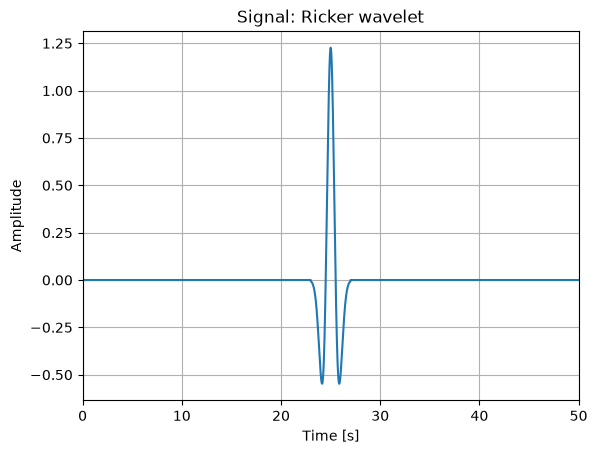

In [5]:
fs = 100.0   # sampling rate in Hz
twin = 50.0  # window length in seconds
t = np.linspace(0, twin, int(twin * fs))

a = 0.5  # width parameter in seconds
t_wavelet = np.arange(-2, 2, 1 / fs)  # 4 seconds of support
sa = ricker(t_wavelet, a)

# place the wavelet in the middle of the time series
pad = len(t) // 2 - len(sa) // 2
s = np.concatenate((np.zeros(pad), sa, np.zeros(len(t) - pad - len(sa))))

plt.figure()
plt.plot(t, s)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.xlim([0, 50])
plt.title('Signal: Ricker wavelet')
plt.show()

The Ricker wavelet is smooth and band-limited. Let's plot its absolute Fourier amplitude spectrum.

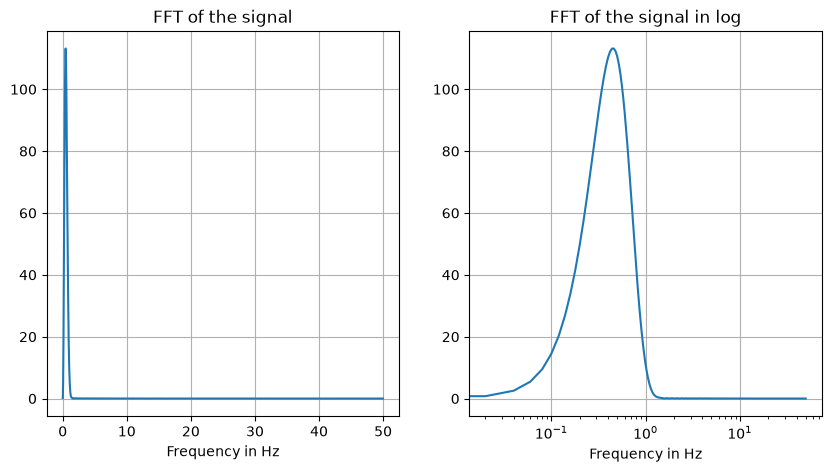

In [6]:
from scipy.fft import fft, fftfreq, next_fast_len

# pad to a fast FFT length
Nfft = next_fast_len(len(s))  # this will be an even number

freqVec = fftfreq(Nfft, d=1 / fs)[: Nfft // 2]
Zhat = fft(s, n=Nfft)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(freqVec, np.abs(Zhat[: Nfft // 2]))
ax[0].grid()
ax[0].set_title('FFT of the signal')
ax[0].set_xlabel('Frequency in Hz')
ax[1].plot(freqVec, np.abs(Zhat[: Nfft // 2]))
ax[1].set_xscale('log')
ax[1].set_xlabel('Frequency in Hz')
ax[1].set_title('FFT of the signal in log')
ax[1].grid()

What does the event data distribution look like?

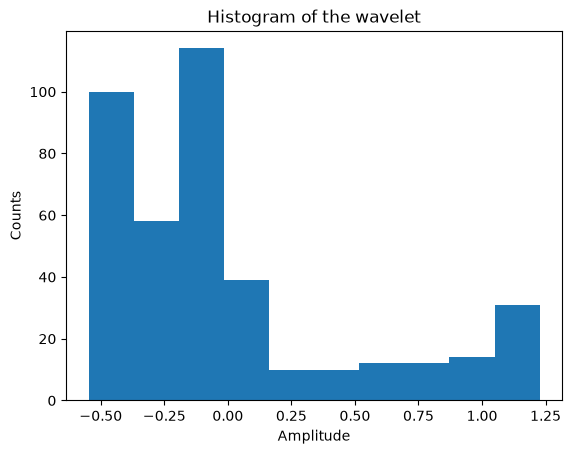

In [7]:
plt.hist(sa, bins=10)
plt.xlabel('Amplitude')
plt.ylabel('Counts')
plt.title('Histogram of the wavelet')
plt.show()

### 3.2 Gaussian noise and signal-to-noise ratio

We created a pure signal. Now we create a *noise* time series to add to it.

One caution: `np.random.uniform(0, 1)` draws values between 0 and 1, which have a mean of 0.5. Adding that to a signal injects a DC offset — a spurious spike at zero frequency in the spectrum. We use `rng.standard_normal` instead, which is zero-mean by construction.

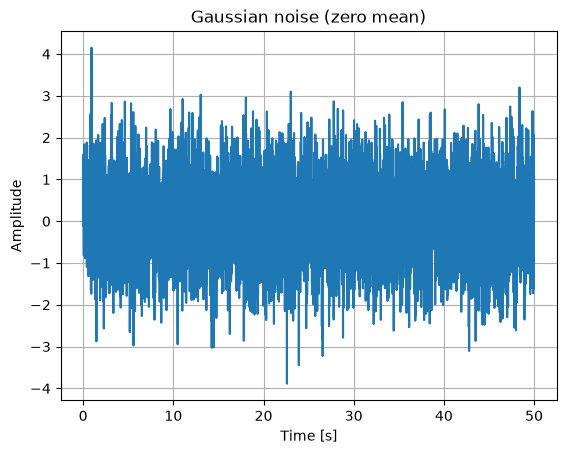

In [8]:
noise = rng.standard_normal(len(s))
plt.figure()
plt.plot(t, noise)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.title('Gaussian noise (zero mean)')
plt.show()

Check the Fourier amplitude spectrum of the noise against the signal spectrum.

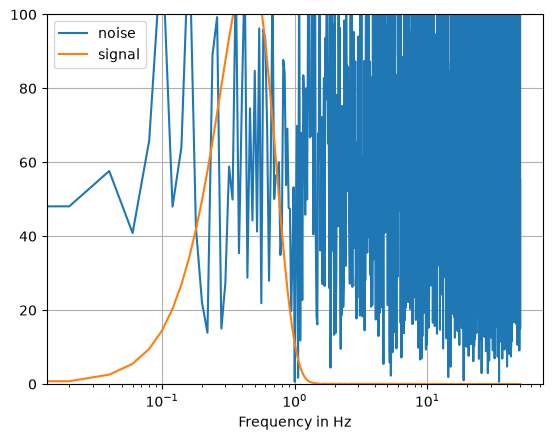

In [9]:
nhat = fft(noise, n=Nfft)
plt.plot(freqVec, np.abs(nhat[: Nfft // 2]))
plt.plot(freqVec, np.abs(Zhat[: Nfft // 2]))
plt.xscale('log')
plt.legend(['noise', 'signal'])
plt.xlabel('Frequency in Hz')
plt.ylim([0, 100])
plt.grid()

They look very different in the spectral domain. The noise spreads its energy over all frequencies; the signal concentrates its energy in a narrow band.

Now we add noise to the signal, scaled by a signal-to-noise ratio (SNR). We define SNR here as the ratio of the maximum absolute amplitude of the signal to that of the noise. First normalize both, then divide the noise by the SNR.

Text(0.5, 0, 'Time in s')

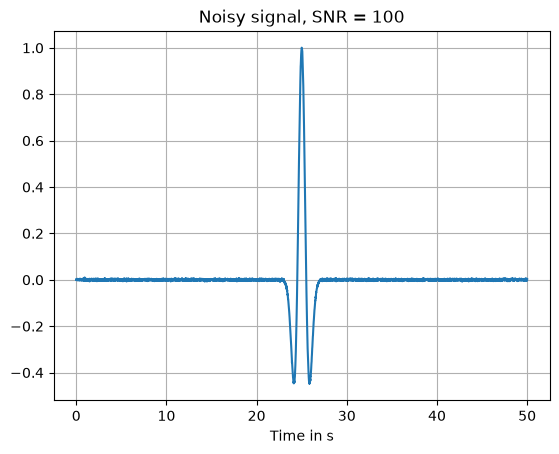

In [10]:
SNR = 100  # signal-to-noise ratio

s /= np.max(np.abs(s))          # normalize the signal
noise /= np.max(np.abs(noise))  # normalize the noise

noisy_signal = s + noise / SNR
plt.plot(t, noisy_signal)
plt.grid()
plt.title(f'Noisy signal, SNR = {SNR}')
plt.xlabel('Time in s')

### 3.3 Noise with a chosen color: randomizing the phase

Noise may have different frequency content, or *color*. A general recipe builds a noise time series from a chosen Fourier amplitude spectrum:
1. Choose the amplitude at each non-negative frequency (flat for white noise, $1/f$ decay for colored noise, or the spectrum of real data).
2. Draw a random phase at each frequency, uniform between $0$ and $2\pi$.
3. Invert with `np.fft.irfft`.

A real-valued time series requires a Hermitian-symmetric spectrum: the value at $-f$ must be the complex conjugate of the value at $+f$. Hand-coding that symmetry is error prone. `irfft` takes only the non-negative frequencies and enforces the symmetry by construction, so we use it. The zero-frequency and Nyquist bins must be real, so we set their phases to zero.

Text(0.5, 1.0, 'Noise with random phase and white spectrum')

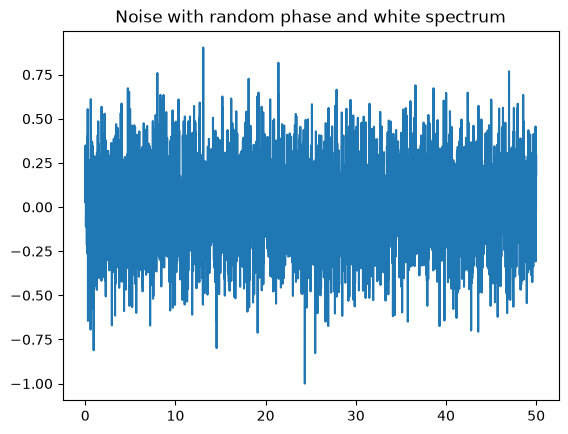

In [11]:
n_rfreq = Nfft // 2 + 1  # number of non-negative frequency bins
phases = rng.uniform(0, 2 * np.pi, n_rfreq)
phases[0] = 0.0    # DC bin must be real
phases[-1] = 0.0   # Nyquist bin must be real (Nfft is even)

amplitude = np.ones(n_rfreq)  # flat spectrum: white noise
amplitude[0] = 0.0            # no DC component

spectrum = amplitude * np.exp(1j * phases)
noise = np.fft.irfft(spectrum, n=Nfft)[: len(s)]

noise /= np.max(np.abs(noise))  # normalize the noise
plt.plot(t, noise)
plt.title('Noise with random phase and white spectrum')

Add the new noise to the signal (Ricker wavelet), this time with a much lower SNR, and plot in the time and frequency domains.

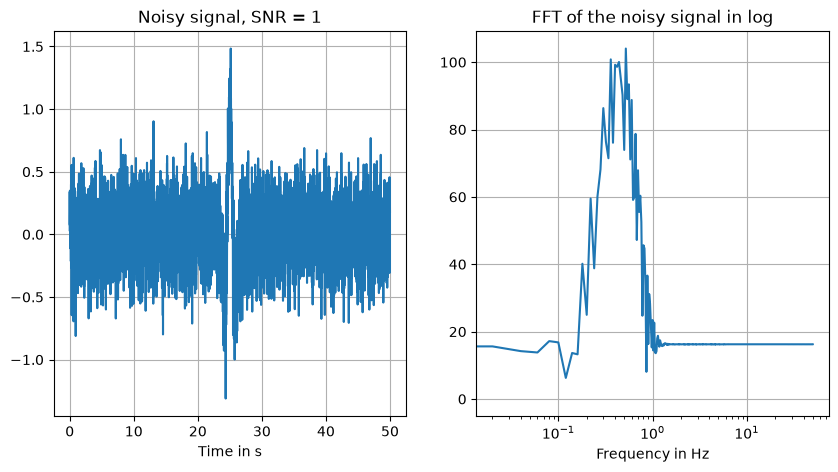

In [12]:
SNR = 1
news = s + noise / SNR

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(t, news)
ax[0].set_title(f'Noisy signal, SNR = {SNR}')
ax[0].set_xlabel('Time in s')
ax[0].grid()
ax[1].plot(freqVec, np.abs(fft(news, n=Nfft)[: Nfft // 2]))
ax[1].set_xscale('log')
ax[1].grid()
ax[1].set_xlabel('Frequency in Hz')
ax[1].set_title('FFT of the noisy signal in log');

Compare the data distributions of the pure signal, the noise, and their sum.

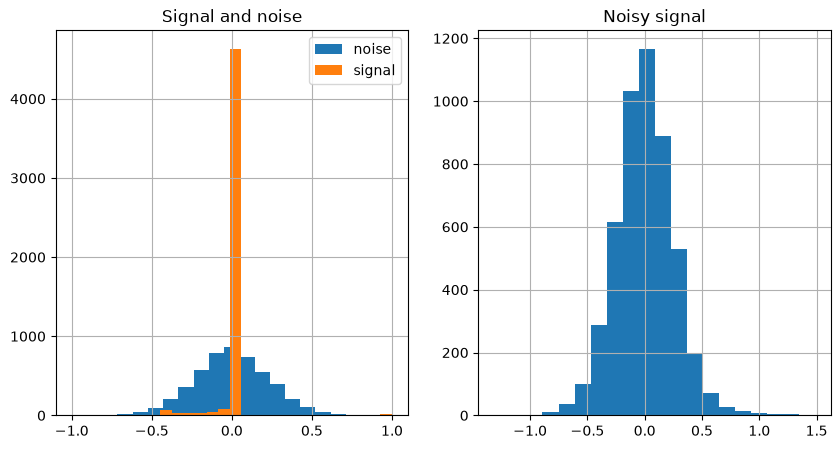

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(noise, bins=20, label='noise')
ax[0].hist(s, bins=20, label='signal')
ax[0].legend()
ax[0].grid()
ax[0].set_title('Signal and noise')
ax[1].hist(news, bins=20)
ax[1].grid()
ax[1].set_title('Noisy signal');

### 3.4 Statistical moments

Calculate the statistical moments of the clean signal and the noise. Which moments discriminate between **signal** and **noise**, and how sensitive are they to the noise level?

In [14]:
from scipy.stats import moment

print('The first moment of the signal is:', moment(s, 1))
print('The second moment of the signal is:', moment(s, 2))
print('The third moment of the signal is:', moment(s, 3))
print('The fourth moment of the signal is:', moment(s, 4))

print('The first moment of the noise is:', moment(noise, 1))
print('The second moment of the noise is:', moment(noise, 2))
print('The third moment of the noise is:', moment(noise, 3))
print('The fourth moment of the noise is:', moment(noise, 4))

The first moment of the signal is: 0.0
The second moment of the signal is: 0.013293333067181288
The third moment of the signal is: 0.006430940666682904
The fourth moment of the signal is: 0.007489819567378666
The first moment of the noise is: 0.0
The second moment of the noise is: 0.0527443916800803
The third moment of the noise is: 6.195710165807209e-05
The fourth moment of the noise is: 0.008719628150564726


The first central moment is zero by definition. The second moment (variance) depends on the normalization, so it is a weak discriminant. The fourth moment is the interesting one: a time series that is mostly zeros with one short transient has heavy tails relative to a Gaussian, so its kurtosis is large. Kurtosis is a workhorse feature for detecting impulsive events in noise, and we will use it again in the feature engineering lesson (2.11).

## 4. Physics-informed synthetic noise from real data

White and colored noise are idealizations. Real seismic noise has structure: microseism peaks, cultural noise during the day, instrument response. To make synthetic noise realistic, we can borrow the amplitude spectrum of real noise and randomize only the phase.

We download two hours of seismic noise recorded at station UW.RATT before an earthquake, using the obspy FDSN client.

In [15]:
import obspy
import obspy.clients.fdsn.client as fdsn
from obspy import UTCDateTime

In [16]:
# Download seismic noise data
network = 'UW'
station = 'RATT'
channel = 'HHZ'  # high-gain broadband, vertical component, 100 Hz
Tstart = UTCDateTime(2021, 7, 29, 6, 15)
fdsn_client = fdsn.Client('IRIS')  # client to query the IRIS DMC server
# download the two hours of noise before the event
N = fdsn_client.get_waveforms(network=network, station=station, location='--',
                              channel=channel, starttime=Tstart - 7200,
                              endtime=Tstart, attach_response=True)
N.merge()
N.detrend(type='linear')
N[0].taper(max_percentage=0.05)
print(N)

/Users/marinedenolle/Dropbox/CLASSES/ESS490/curriculum-book/.pixi/envs/default/lib/python3.12/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_34339/286277248.py:8: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  N = fdsn_client.get_waveforms(network=network, station=station, location='--',


1 Trace(s) in Stream:
UW.RATT..HHZ | 2021-07-29T04:15:00.000000Z - 2021-07-29T06:14:59.990000Z | 100.0 Hz, 720000 samples


### 4.1 Spectrum-matched noise

We now generate synthetic noise whose amplitude spectrum matches the real RATT noise. The course package `mlgeo_synth` provides `spectrum_matched_noise`, which keeps the amplitude spectrum of a reference record and draws random phases. It uses `rfft`/`irfft`, so the Hermitian symmetry needed for a real-valued output is guaranteed by construction. Run `help(mlgeo_synth.spectrum_matched_noise)` to see the signature.

In [17]:
import mlgeo_synth

real_noise = N[0].data.astype(float)
real_noise -= real_noise.mean()
fs_real = N[0].stats.sampling_rate

synthetic_noise = mlgeo_synth.spectrum_matched_noise(real_noise, seed=42)
print(real_noise.shape, synthetic_noise.shape)

(720000,) (720000,)


Compare the two in the time domain and in the frequency domain. The time series should look different — the phases are different, so the waveforms line up nowhere. The amplitude spectra should overlap exactly, because the synthetic spectrum is a copy of the real one.

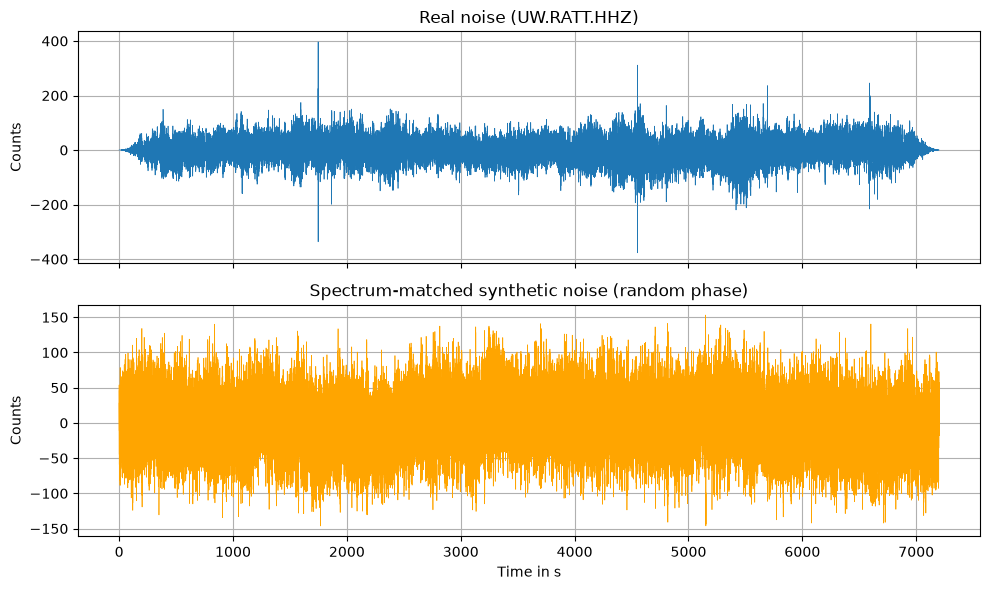

In [18]:
t_real = np.arange(len(real_noise)) / fs_real

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(t_real, real_noise, lw=0.5)
ax[0].set_title('Real noise (UW.RATT.HHZ)')
ax[0].set_ylabel('Counts')
ax[0].grid()
ax[1].plot(t_real, synthetic_noise, lw=0.5, color='orange')
ax[1].set_title('Spectrum-matched synthetic noise (random phase)')
ax[1].set_xlabel('Time in s')
ax[1].set_ylabel('Counts')
ax[1].grid()
plt.tight_layout()
plt.show()

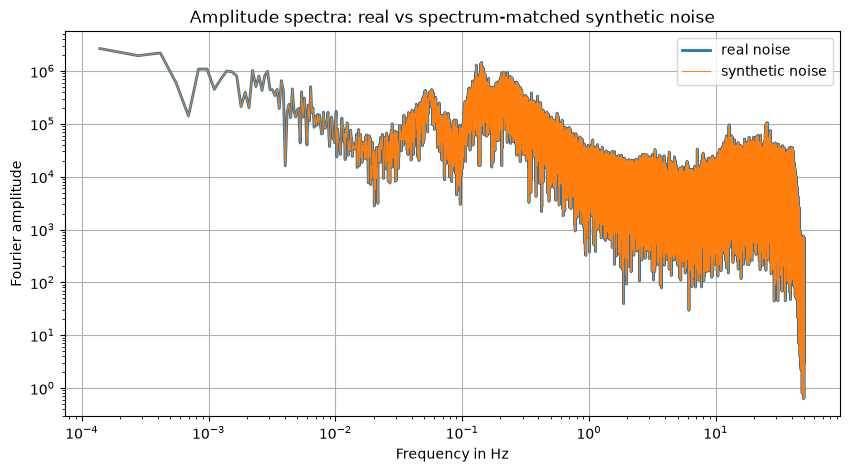

In [19]:
Nfft_real = next_fast_len(len(real_noise))
freq_real = np.fft.rfftfreq(Nfft_real, d=1 / fs_real)

spec_real = np.abs(np.fft.rfft(real_noise, n=Nfft_real))
spec_synth = np.abs(np.fft.rfft(synthetic_noise, n=Nfft_real))

plt.figure(figsize=(10, 5))
plt.loglog(freq_real[1:], spec_real[1:], lw=2, label='real noise')
plt.loglog(freq_real[1:], spec_synth[1:], lw=0.7, label='synthetic noise')
plt.xlabel('Frequency in Hz')
plt.ylabel('Fourier amplitude')
plt.title('Amplitude spectra: real vs spectrum-matched synthetic noise')
plt.legend()
plt.grid()
plt.show()

The two spectra lie on top of each other: the amplitude information is identical. The phase information is not. We can check that directly.

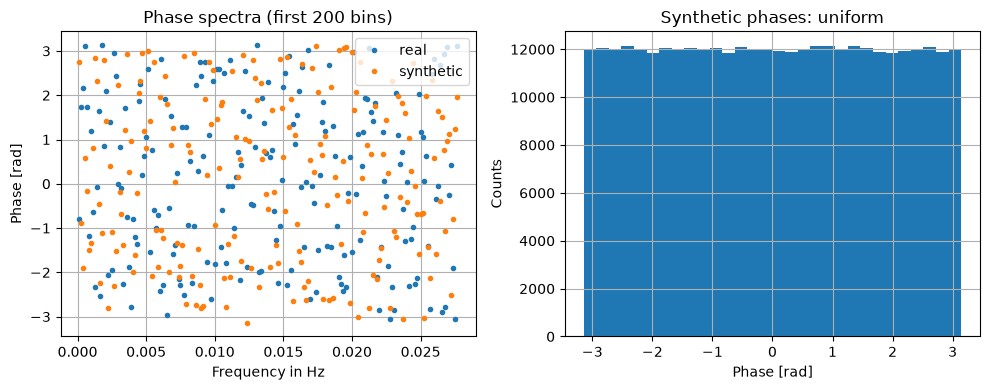

In [20]:
phase_real = np.angle(np.fft.rfft(real_noise, n=Nfft_real))
phase_synth = np.angle(np.fft.rfft(synthetic_noise, n=Nfft_real))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(freq_real[1:200], phase_real[1:200], '.', label='real')
ax[0].plot(freq_real[1:200], phase_synth[1:200], '.', label='synthetic')
ax[0].set_xlabel('Frequency in Hz')
ax[0].set_ylabel('Phase [rad]')
ax[0].set_title('Phase spectra (first 200 bins)')
ax[0].legend()
ax[0].grid()
ax[1].hist(phase_synth, bins=30)
ax[1].set_xlabel('Phase [rad]')
ax[1].set_ylabel('Counts')
ax[1].set_title('Synthetic phases: uniform')
ax[1].grid()
plt.tight_layout()
plt.show()

### 4.2 Augmenting an event with realistic noise at varying SNR

Now we combine the two ideas: a synthetic event (the Ricker wavelet) plus spectrum-matched realistic noise, at a range of SNR levels. This is a standard data augmentation strategy: one clean event template yields many training samples with controlled noise levels.

`spectrum_matched_noise` accepts an output length `n`, so we can draw a noise realization of the same length as the signal window.

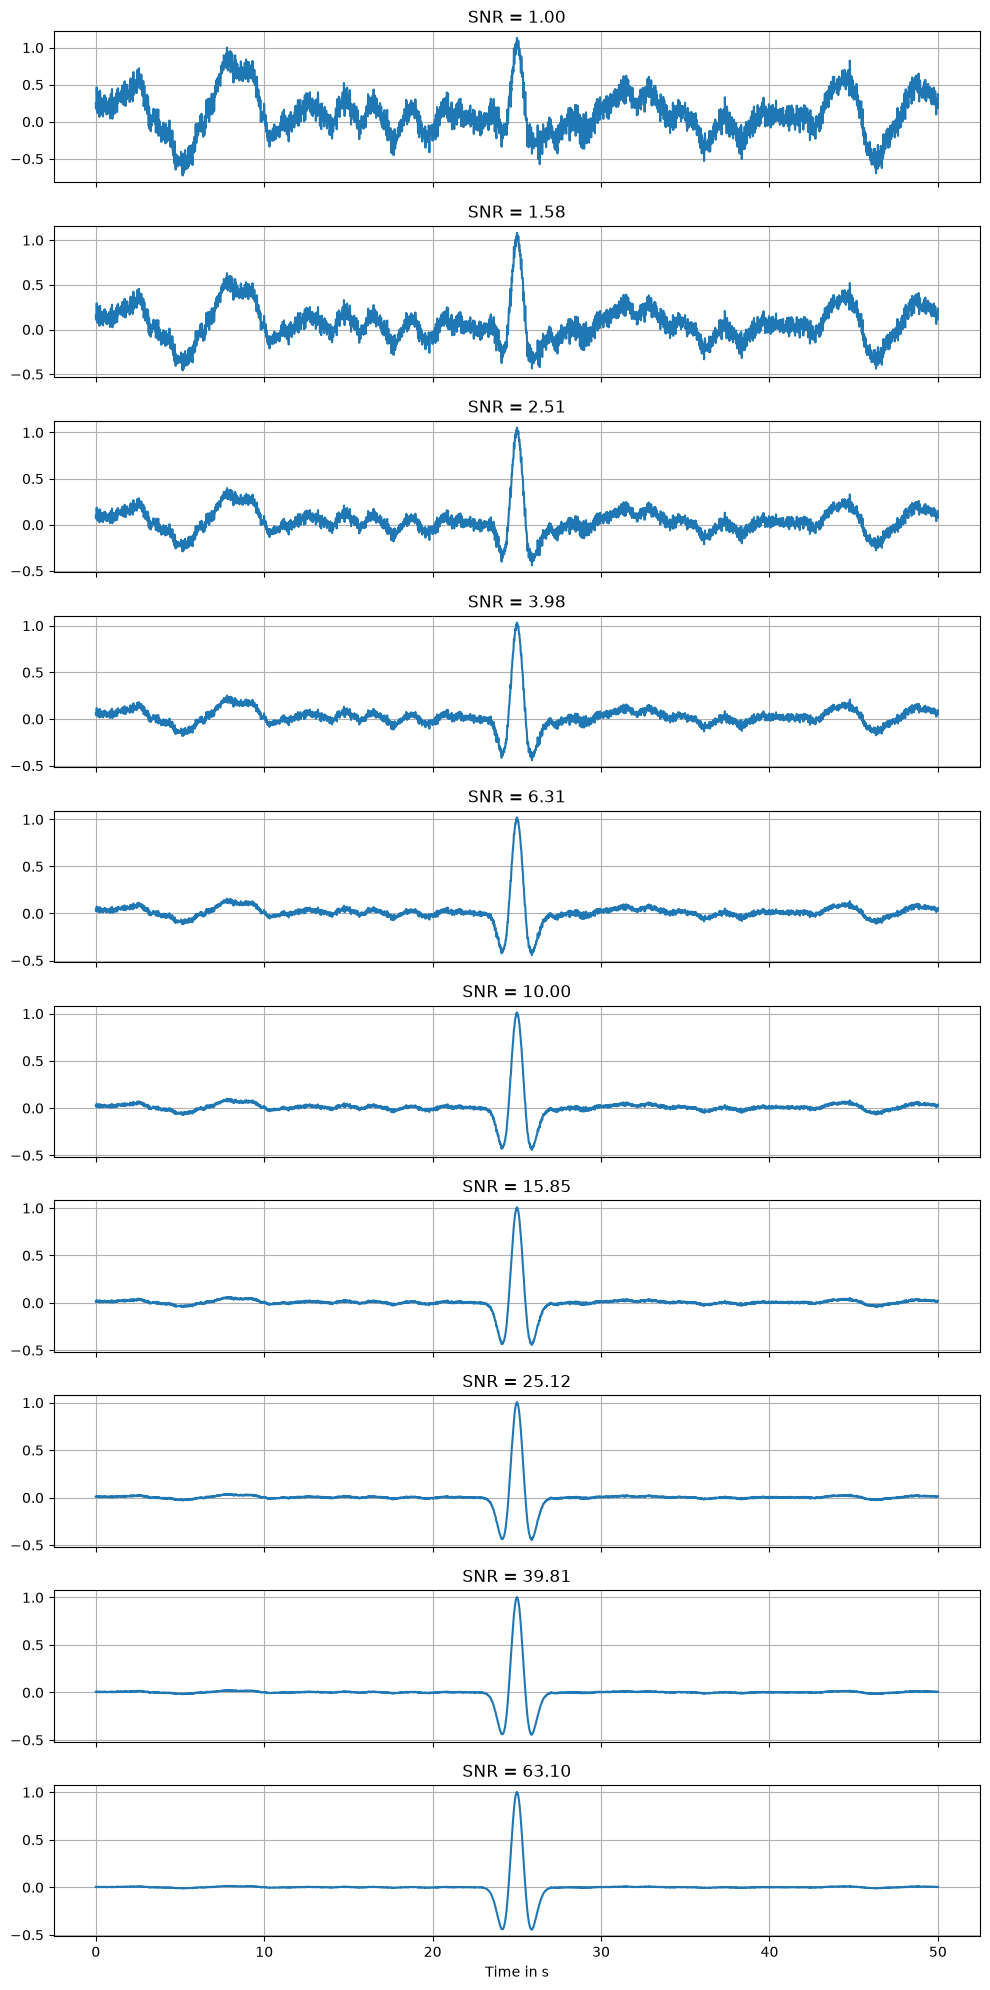

In [21]:
matched_noise = mlgeo_synth.spectrum_matched_noise(real_noise, n=len(s), seed=7)
matched_noise /= np.max(np.abs(matched_noise))

snr_levels = [np.power(10, i / 5) for i in range(10)]
fig, ax = plt.subplots(10, 1, figsize=(10, 20), sharex=True)
for i, snr in enumerate(snr_levels):
    ax[i].plot(t, s + matched_noise / snr)
    ax[i].set_title(f'SNR = {snr:.2f}')
    ax[i].grid()
ax[-1].set_xlabel('Time in s')
plt.tight_layout()
plt.show()

At low SNR the event disappears into the noise. Somewhere along this ladder, any detector — human or algorithmic — starts to fail. Finding that failure point is the subject of the second exercise below.

### 4.3 The course synthetic-data generator

The `mlgeo_synth` package used above is the course's synthetic-data generator. Besides `spectrum_matched_noise`, it can generate full synthetic seismograms with a P wave, an S wave, a coda, and colored noise, plus labeled datasets for classification exercises. We will rely on it in later chapters when we need data with known ground truth.

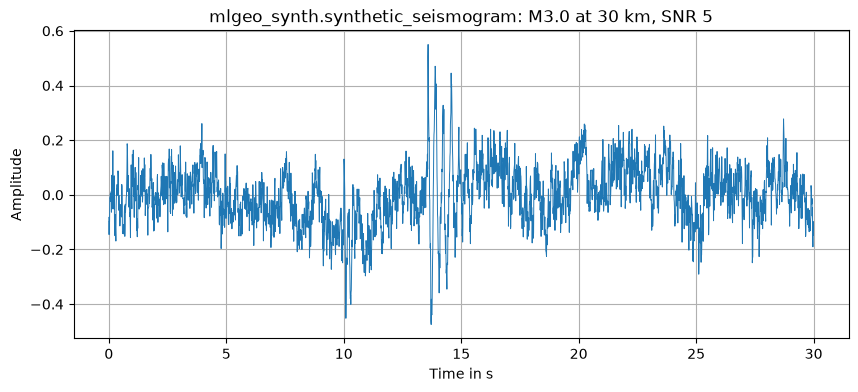

{'t_p': 10.0, 't_s': 13.571428571428571, 'peak_amplitude': np.float64(0.4841325757612952), 'snr': 5.0}


In [22]:
t_syn, trace, meta = mlgeo_synth.synthetic_seismogram(
    duration_s=30.0, fs=100.0, magnitude=3.0, distance_km=30.0, snr=5.0, seed=3)

plt.figure(figsize=(10, 4))
plt.plot(t_syn, trace, lw=0.7)
plt.xlabel('Time in s')
plt.ylabel('Amplitude')
plt.title('mlgeo_synth.synthetic_seismogram: M3.0 at 30 km, SNR 5')
plt.grid()
plt.show()
print(meta)

## 5. Exercises

### Exercise 1: spectrum-matched noise from a different reference window

Download a different two-hour noise window from UW.RATT (for example, 24 hours earlier), generate spectrum-matched noise from it, and compare with the window used above:
1. Compare the variance and kurtosis of the two real windows and their two synthetic versions.
2. Overlay the four amplitude spectra. Do the microseism peaks move between days?
3. Comment: is one synthetic noise window enough to represent the noise at this station?

In [23]:
# Exercise 1 scaffold
# Tstart2 = Tstart - 86400  # 24 hours earlier
# N2 = fdsn_client.get_waveforms(network=network, station=station, location='--',
#                                channel=channel, starttime=Tstart2 - 7200,
#                                endtime=Tstart2, attach_response=True)
# N2.merge(); N2.detrend(type='linear'); N2[0].taper(max_percentage=0.05)
# real_noise2 = N2[0].data.astype(float) - N2[0].data.mean()
# synthetic_noise2 = mlgeo_synth.spectrum_matched_noise(real_noise2, seed=42)
# from scipy.stats import kurtosis
# ... compare np.var and kurtosis of the four series, then overlay their spectra

### Exercise 2: when does an STA/LTA detector fail?

The STA/LTA (short-term average over long-term average) detector is the classic trigger for seismic events. Augment the Ricker event with spectrum-matched noise at a range of SNRs and measure where the detector stops working:
1. For each SNR in `np.logspace(-1, 2, 20)`, build `s + matched_noise / snr` with a fresh noise seed.
2. Run `obspy.signal.trigger.classic_sta_lta` with a short window of 1 s (100 samples) and a long window of 10 s (1000 samples).
3. Record the peak STA/LTA value for each SNR and plot it against SNR on a log axis.
4. With a trigger threshold of 3, at what SNR does detection fail? Does the failure point change with a different noise seed?

In [24]:
# Exercise 2 scaffold
# from obspy.signal.trigger import classic_sta_lta
# peaks = []
# snrs = np.logspace(-1, 2, 20)
# for k, snr in enumerate(snrs):
#     noise_k = mlgeo_synth.spectrum_matched_noise(real_noise, n=len(s), seed=100 + k)
#     noise_k /= np.max(np.abs(noise_k))
#     trace_k = s + noise_k / snr
#     cft = classic_sta_lta(trace_k, int(1 * fs), int(10 * fs))
#     peaks.append(cft.max())
# plt.semilogx(snrs, peaks, 'o-')
# plt.axhline(3, color='r', ls='--', label='trigger threshold')
# ... at what SNR does the peak drop below the threshold?

## 6. When is synthetic data admissible?

Synthetic data is a tool, not a substitute for observation. Use this checklist before putting synthetic data into a project.

**Admissible:**
- **Method development.** Prototyping a detector, a filter, or a model on data with known ground truth before touching real data.
- **Benchmarking.** Measuring accuracy, recall, or failure points (as in Exercise 2) requires knowing the true answer. Synthetic data provides it.
- **Augmentation with disclosed provenance.** Adding noise realizations or synthetic events to a training set is standard practice, as long as the paper or report states which samples are synthetic and how they were generated.
- **Hidden test sets.** Instructors and benchmark maintainers use synthetic data to build test sets that models cannot have memorized.

**Not admissible:**
- **Substituting for real validation in scientific claims.** A model validated only on synthetic data has not been validated. A scientific conclusion about the Earth must rest on real observations.

**Always disclose.** Whenever synthetic data enters an analysis, say so: which samples, which generator, which seed. The generator code and seeds belong in the repository with the rest of the project. In this course, use the `mlgeo_synth` package as the generator so that provenance is one import away, and follow the project guidance in [the MLGeo project instructions](../about_this_book/0_mlgeo_project.md).